# 09 · Strategy Layer: From Scores to Approval Decisions

**Decision flow:** application → **admission rule** (age) → **scorecard** → **risk grade A–E** →
**action** (auto-approve / standard approve / manual review / decline)

**Set-up**
- Champion = the scorecard chosen in notebook 08; LightGBM = challenger.
- Cut-offs and grade boundaries are **set on the validation period (weeks 41–50)** — "the most recent data before
  go-live" — and then applied unchanged to OOT1 and OOT2.
- All business parameters are in the first code cell; change them and re-run to get a new policy.

**Reading the numbers**
- The data contains **booked loans only**. "Approval rate" means the share of historically approved applicants the
  policy would keep; "decline" means removing them. This selection bias affects all compared policies equally.
- Bad rate is by count; "bad amount share" = loan amount of bad customers / total loan amount (no LGD assumed).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from hcrisk.config import FEAT_DIR, OOT1_END, PERIOD_LABEL, RES_DIR, VALID_END, savefig
from hcrisk.metrics import psi_by_deciles
from hcrisk.strategy import GRADE_LABELS, grade_cuts

# ================= business parameters =================
TARGET_RATES = [0.70, 0.80, 0.90]     # approval rates compared
BASE_RATE = 0.80                      # main approval-rate target
AGE_MIN, AGE_MAX = 22, None           # admission: lower bound 22; no upper bound by default (see section 1)
AGE_MAX_OPTIONS = [55, 60, 65]        # upper bounds evaluated for impact only
GRADES = [("A", 0.30, "auto-approve"), ("B", 0.25, "auto-approve"), ("C", 0.20, "standard approve"),
          ("D", 0.15, "manual review"), ("E", 0.10, "decline")]
ROLL_WEEKS = 4                        # rolling cut-off: score distribution of the last 4 weeks (no labels needed)
LABEL_LAG, TRIGGER, TIGHTEN = 13, 1.2, 0.05   # layer 2: labels visible after 13 weeks; trigger at 1.2x baseline; -5pp
MON_SIGMA = 3.0                       # business-metric alerts: validation mean +/- 3 weekly standard deviations
# =======================================================

SC = json.loads((RES_DIR / "08_decision.json").read_text())["chosen_scorecard"]
P = (pl.read_parquet(RES_DIR / "08_predictions.parquet")
       .join(pl.read_parquet(RES_DIR / "age.parquet"), on="case_id", how="left"))
d0_cols = list(pl.read_parquet_schema(FEAT_DIR / "depth0.parquet"))
amt_col = next((c for c in ["credamount_770A", "disbursedcredamount_1113A"] if c in d0_cols), None)
if amt_col:
    P = P.join(pl.read_parquet(FEAT_DIR / "depth0.parquet", columns=["case_id", amt_col]).rename({amt_col: "amount"}), on="case_id", how="left")
else:
    P = P.with_columns(pl.lit(None, pl.Float64).alias("amount"))
P = P.with_columns((-pl.col(f"score_{SC}")).alias("risk_SC"), (-pl.col("score_A")).alias("risk_A"),
                   (-pl.col("score_B")).alias("risk_B"), pl.col("p_lgb").alias("risk_LGB"))
EVAL = ["2_valid", "3_oot1", "4_oot2"]
print(f"champion: scorecard {SC} | challenger: LightGBM | loan amount field: {amt_col}")


def kpi(df, mask=None):
    d = df if mask is None else df.filter(mask)
    out = {"n": d.height, "bad_rate": d["target"].mean()}
    if amt_col:
        a = d["amount"].fill_null(0)
        out["amount"] = a.sum()
        out["bad_amount_share"] = (a * d["target"]).sum() / max(a.sum(), 1)
    return out

champion: scorecard A | challenger: LightGBM | loan amount field: credamount_770A


## 1. Admission rule: age
- **Lower bound:** under-22s have ~2× the average bad rate in the full data and are ~1% of volume → cheap and effective.
- **Upper bound:** the bad rate *falls* with age, so the oldest applicants are the safest. There is **no risk-based
  case** for an upper limit. The table quantifies what 55 / 60 / 65 limits would cost, for business to weigh against
  non-risk reasons (repayment capacity over the term, vulnerable-customer policies). Not applied by default.

In [2]:
def age_ok(lo=AGE_MIN, hi=AGE_MAX):
    m = pl.lit(True)
    if lo is not None:
        m = m & ((pl.col("age") >= lo) | pl.col("age").is_null())
    if hi is not None:
        m = m & ((pl.col("age") <= hi) | pl.col("age").is_null())
    return m

rows = []
for p in EVAL:
    d = P.filter(pl.col("period") == p)
    rules = [(f"age < {AGE_MIN}: decline", ~age_ok(AGE_MIN, None))] + [(f"(option) age > {h}: decline", pl.col("age") > h) for h in AGE_MAX_OPTIONS]
    for name, rej in rules:
        rows.append({"period": PERIOD_LABEL[p], "rule": name, "declined_share": d.filter(rej).height / d.height,
                     "declined_bad_rate": d.filter(rej)["target"].mean(), "remaining_bad_rate": d.filter(~rej)["target"].mean()})
display(pl.DataFrame(rows).with_columns(pl.exclude("period", "rule").round(4)))
P = P.with_columns(age_ok().alias("admit"))

period,rule,declined_share,declined_bad_rate,remaining_bad_rate
str,str,f64,f64,f64
"""Valid""","""age < 22: decline""",0.0117,0.0712,0.0364
"""Valid""","""(option) age > 55: decline""",0.2329,0.0264,0.0399
"""Valid""","""(option) age > 60: decline""",0.1545,0.0255,0.0388
"""Valid""","""(option) age > 65: decline""",0.0819,0.0284,0.0375
"""OOT1""","""age < 22: decline""",0.01,0.0752,0.0423
…,…,…,…,…
"""OOT1""","""(option) age > 65: decline""",0.0912,0.0317,0.0438
"""OOT2""","""age < 22: decline""",0.008,0.0802,0.0229
"""OOT2""","""(option) age > 55: decline""",0.3636,0.0136,0.029


## 2. Risk grades and decision matrix
Admitted applicants are split by validation-period score quantiles into A (30%), B (25%), C (20%), D (15%), E (10%).
With boundaries fixed, grade shares that move in OOT reveal score drift; bad rates should stay monotonic.

In [3]:
ref = P.filter((pl.col("period") == "2_valid") & pl.col("admit"))[f"score_{SC}"].to_numpy()
CUTS = grade_cuts(ref, [g[1] for g in GRADES])
labels, action = [g[0] for g in GRADES], {g[0]: g[2] for g in GRADES}
e = pl.when(pl.col(f"score_{SC}") >= CUTS[0]).then(pl.lit(labels[0]))
for cut, lab in zip(CUTS[1:], labels[1:-1]):
    e = e.when(pl.col(f"score_{SC}") >= cut).then(pl.lit(lab))
P = P.with_columns(pl.when(~pl.col("admit")).then(pl.lit("admission decline")).otherwise(e.otherwise(pl.lit(labels[-1]))).alias("grade"))
print("grade boundaries (score): " + " | ".join(f"{a} >= {c:.0f}" for a, c in zip(labels, CUTS)) + f" | {labels[-1]} < {CUTS[-1]:.0f}")

rows = []
for p in EVAL:
    d = P.filter(pl.col("period") == p)
    for g in ["admission decline"] + labels:
        k = kpi(d, pl.col("grade") == g)
        rows.append({"period": PERIOD_LABEL[p], "grade": g, "action": "decline" if g == "admission decline" else action[g],
                     "share": k["n"] / d.height, "bad_rate": k["bad_rate"]})
matrix = pl.DataFrame(rows).with_columns(pl.col("share", "bad_rate").round(4))
display(matrix.pivot(on="period", index=["grade", "action"], values="share").with_columns(pl.lit("volume share").alias("metric")))
display(matrix.pivot(on="period", index=["grade", "action"], values="bad_rate").with_columns(pl.lit("bad rate").alias("metric")))

grade boundaries (score): A >= 628 | B >= 607 | C >= 587 | D >= 565 | E < 565


grade,action,Valid,OOT1,OOT2,metric
str,str,f64,f64,f64,str
"""admission decline""","""decline""",0.0117,0.01,0.008,"""volume share"""
"""A""","""auto-approve""",0.3046,0.3053,0.3876,"""volume share"""
"""B""","""auto-approve""",0.2447,0.2383,0.2298,"""volume share"""
"""C""","""standard approve""",0.1972,0.1903,0.1634,"""volume share"""
"""D""","""manual review""",0.1454,0.1455,0.1206,"""volume share"""
"""E""","""decline""",0.0964,0.1106,0.0907,"""volume share"""


grade,action,Valid,OOT1,OOT2,metric
str,str,f64,f64,f64,str
"""admission decline""","""decline""",0.0712,0.0752,0.0802,"""bad rate"""
"""A""","""auto-approve""",0.0057,0.0072,0.0033,"""bad rate"""
"""B""","""auto-approve""",0.0155,0.0196,0.0108,"""bad rate"""
"""C""","""standard approve""",0.0345,0.0393,0.0227,"""bad rate"""
"""D""","""manual review""",0.0674,0.0731,0.0458,"""bad rate"""
"""E""","""decline""",0.1432,0.1531,0.1076,"""bad rate"""


In [4]:
auto = pl.col("grade").is_in([g[0] for g in GRADES if g[2] in ("auto-approve", "standard approve")])
review = pl.col("grade").is_in([g[0] for g in GRADES if g[2] == "manual review"])
rows = []
for p in EVAL:
    d = P.filter(pl.col("period") == p)
    b, a = kpi(d), kpi(d, auto)
    rows.append({"period": PERIOD_LABEL[p], "direct_approval_rate": a["n"] / d.height, "manual_review_share": d.filter(review).height / d.height,
                 "decline_rate": 1 - (a["n"] + d.filter(review).height) / d.height, "bad_rate_all": b["bad_rate"],
                 "bad_rate_direct_approved": a["bad_rate"], "bad_rate_manual_review": d.filter(review)["target"].mean(),
                 **({"bad_amount_share_all": b["bad_amount_share"], "bad_amount_share_direct": a["bad_amount_share"]} if amt_col else {})})
outcome = pl.DataFrame(rows).with_columns(pl.exclude("period").round(4))
display(outcome)

period,direct_approval_rate,manual_review_share,decline_rate,bad_rate_all,bad_rate_direct_approved,bad_rate_manual_review,bad_amount_share_all,bad_amount_share_direct
str,f64,f64,f64,f64,f64,f64,f64,f64
"""Valid""",0.7464,0.1454,0.1081,0.0368,0.0165,0.0674,0.0406,0.0203
"""OOT1""",0.7339,0.1455,0.1206,0.0427,0.0195,0.0731,0.0528,0.0278
"""OOT2""",0.7808,0.1206,0.0986,0.0234,0.0096,0.0458,0.028,0.0132


## 3. Approval rate vs bad rate
Lower curves carry less risk for the same lending volume. The table compares models at 70/80/90% approval —
a **business view** of model quality that looks only at decisions near the cut-off.

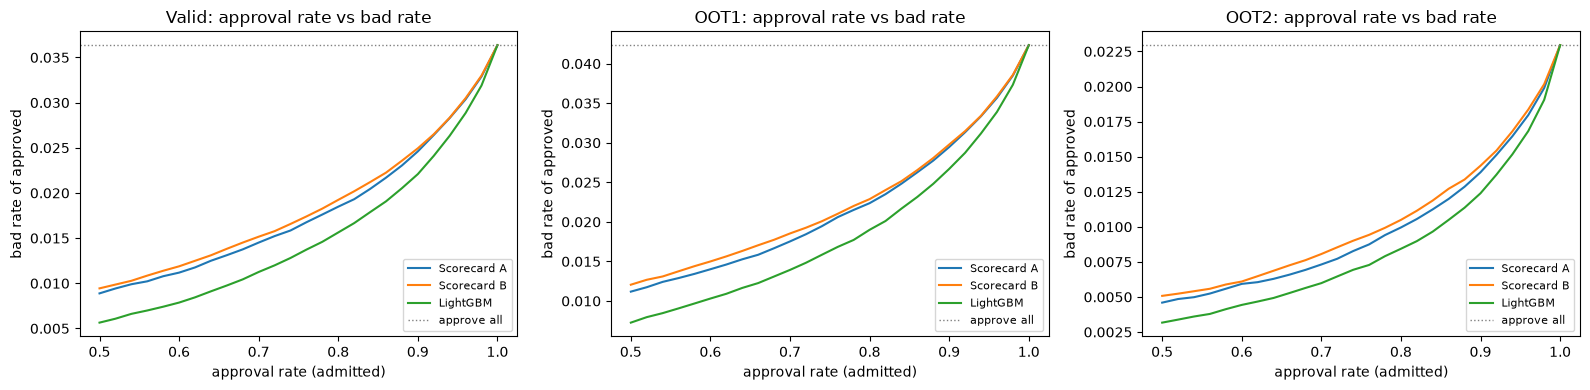

period,approval_rate,Scorecard A,Scorecard B,LightGBM
str,f64,f64,f64,f64
"""Valid""",0.7,0.0145,0.0152,0.0113
"""Valid""",0.8,0.0185,0.0192,0.0156
"""Valid""",0.9,0.0246,0.0249,0.0221
"""OOT1""",0.7,0.0175,0.0185,0.0139
"""OOT1""",0.8,0.0224,0.0229,0.019
"""OOT1""",0.9,0.0295,0.0298,0.0267
"""OOT2""",0.7,0.0073,0.0081,0.006
"""OOT2""",0.8,0.01,0.0105,0.0084
"""OOT2""",0.9,0.0139,0.0144,0.0124


In [5]:
MODELS = {"Scorecard A": "risk_A", "Scorecard B": "risk_B", "LightGBM": "risk_LGB"}
rates = np.linspace(0.5, 1.0, 26)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
rows = []
for ax, p in zip(axes, EVAL):
    d = P.filter((pl.col("period") == p) & pl.col("admit"))
    y = d["target"].to_numpy()
    for name, col in MODELS.items():
        ys = y[np.argsort(d[col].to_numpy())]
        br = [ys[:int(round(r * len(ys)))].mean() for r in rates]
        ax.plot(rates, br, label=name)
        rows += [{"period": PERIOD_LABEL[p], "model": name, "approval_rate": r, "bad_rate": br[int(np.argmin(np.abs(rates - r)))]} for r in TARGET_RATES]
    ax.axhline(y.mean(), color="grey", ls=":", lw=1, label="approve all")
    ax.set_title(f"{PERIOD_LABEL[p]}: approval rate vs bad rate"); ax.set_xlabel("approval rate (admitted)"); ax.set_ylabel("bad rate of approved")
    ax.legend(fontsize=8)
plt.tight_layout(); savefig(fig, "09_approval_badrate_curves"); plt.show()
biz = pl.DataFrame(rows)
display(biz.pivot(on="model", index=["period", "approval_rate"], values="bad_rate").with_columns(pl.exclude("period", "approval_rate").round(4)))

### Business rule vs competition rule for A vs B
Notebook 08 chose the scorecard with the competition metric. Here: at equal approval rates in OOT, which version has
the lower bad rate (a win needs > 0.05 pp)? In the full data both criteria pick version A.

In [6]:
ab = (biz.filter(pl.col("model").is_in(["Scorecard A", "Scorecard B"]) & pl.col("period").is_in(["OOT1", "OOT2"]))
         .pivot(on="model", index=["period", "approval_rate"], values="bad_rate")
         .with_columns(((pl.col("Scorecard A") - pl.col("Scorecard B")) * 100).round(3).alias("A - B (pp)")))
display(ab)
print(f"business criterion: A wins {(ab['A - B (pp)'] < -0.05).sum()}, B wins {(ab['A - B (pp)'] > 0.05).sum()}, "
      f"ties {ab.height - (ab['A - B (pp)'].abs() > 0.05).sum()} | competition criterion (08): {SC}")

period,approval_rate,Scorecard A,Scorecard B,A - B (pp)
str,f64,f64,f64,f64
"""OOT1""",0.7,0.017529,0.018537,-0.101
"""OOT1""",0.8,0.022364,0.022874,-0.051
"""OOT1""",0.9,0.029458,0.029774,-0.032
"""OOT2""",0.7,0.007314,0.008059,-0.075
"""OOT2""",0.8,0.009953,0.010493,-0.054
"""OOT2""",0.9,0.013886,0.014354,-0.047


business criterion: A wins 4, B wins 0, ties 2 | competition criterion (08): A


## 4. Swap-set analysis: scorecard → LightGBM
At the same approval rate: **swap-in** = declined by the scorecard but approved by LightGBM; **swap-out** = the
reverse. Replacing the model pays off if swap-ins are safer than swap-outs. This is the offline analogue of an A/B test.

In [7]:
detail, rows = [], []
for p in EVAL:
    d = P.filter((pl.col("period") == p) & pl.col("admit"))
    for r in TARGET_RATES:
        s = d.with_columns((pl.col("risk_SC") <= np.quantile(d["risk_SC"].to_numpy(), r)).alias("ok_sc"),
                           (pl.col("risk_LGB") <= np.quantile(d["risk_LGB"].to_numpy(), r)).alias("ok_lgb"))
        for g, m in {"both approve": pl.col("ok_sc") & pl.col("ok_lgb"), "swap-in (LGB approves)": ~pl.col("ok_sc") & pl.col("ok_lgb"),
                     "swap-out (scorecard approves)": pl.col("ok_sc") & ~pl.col("ok_lgb"), "both decline": ~pl.col("ok_sc") & ~pl.col("ok_lgb")}.items():
            detail.append({"period": PERIOD_LABEL[p], "approval_rate": r, "group": g, "share": s.filter(m).height / s.height,
                           "bad_rate": s.filter(m)["target"].mean()})
        b_sc, b_lgb = s.filter(pl.col("ok_sc"))["target"].sum(), s.filter(pl.col("ok_lgb"))["target"].sum()
        rows.append({"period": PERIOD_LABEL[p], "approval_rate": r, "approved": int(s["ok_sc"].sum()), "bads_scorecard": int(b_sc),
                     "bads_lightgbm": int(b_lgb), "bads_avoided_pct": round((b_sc - b_lgb) / b_sc, 4)})
swap = pl.DataFrame(detail).with_columns(pl.col("share", "bad_rate").round(4))
display(swap.filter(pl.col("approval_rate") == BASE_RATE).pivot(on="period", index="group", values=["share", "bad_rate"]))
display(pl.DataFrame(rows))

group,share_Valid,share_OOT1,share_OOT2,bad_rate_Valid,bad_rate_OOT1,bad_rate_OOT2
str,f64,f64,f64,f64,f64,f64
"""both approve""",0.7516,0.7489,0.7479,0.0139,0.0171,0.0074
"""swap-in (LGB approves)""",0.0484,0.0511,0.0521,0.043,0.0475,0.0232
"""swap-out (scorecard approves)""",0.0568,0.0513,0.0523,0.0843,0.0998,0.0464
"""both decline""",0.1432,0.1487,0.1477,0.1331,0.148,0.0932


period,approval_rate,approved,bads_scorecard,bads_lightgbm,bads_avoided_pct
str,f64,i64,i64,i64,f64
"""Valid""",0.7,174338,2541,1956,0.2302
"""Valid""",0.8,200756,3777,3105,0.1779
"""Valid""",0.9,224121,5561,4937,0.1122
"""OOT1""",0.7,166372,2956,2295,0.2236
"""OOT1""",0.8,188348,4211,3577,0.1506
"""OOT1""",0.9,212282,6282,5655,0.0998
"""OOT2""",0.7,180236,1329,1076,0.1904
"""OOT2""",0.8,205535,2047,1733,0.1534
"""OOT2""",0.9,231293,3219,2864,0.1103


## 5. Cut-off maintenance
| Policy | Rule |
|---|---|
| fixed | set on valid, never changed — approval rate drifts with the score distribution |
| rolling | every week, re-set from the last 4 weeks' scores to hold 80% approval — stable volume, but loosens when applicants get riskier |
| **layer 1 (adopted)** | rolling, but never looser than the validation baseline — holds volume when the population improves, holds the risk floor when it deteriorates; uses scores only, no lag |
| layer 1 + 2 | plus: when the approved bad rate observed with a 13-week label lag exceeds 1.2× baseline, cut the target by 5 pp |

In the full data layer 2 fires in weeks ~70–77 — *after* the OOT1 deterioration had passed — and tightens exactly when
risk is lowest: a **lagging signal acts pro-cyclically**. Layer 2 is therefore not adopted until leading indicators
(e.g. first-payment default, early delinquency, macro indicators) are available.

baseline cut-off = score 581 | approved bad rate on valid 1.88% | layer-2 trigger 2.26%


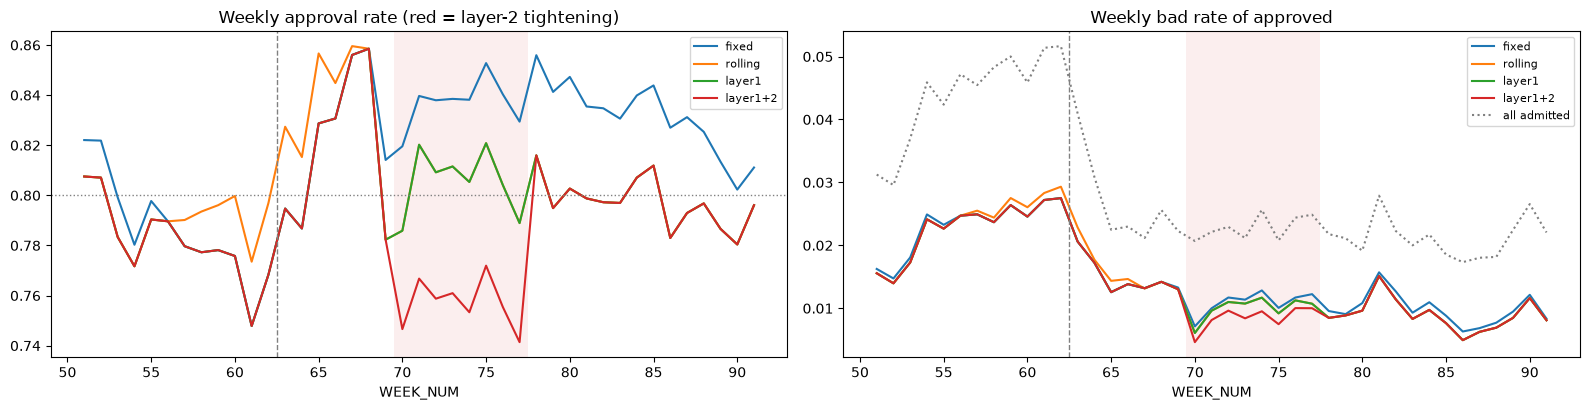

layer-2 tightening weeks: [70, 71, 72, 73, 74, 75, 76, 77]


period,policy,avg_approval,max_deviation,approved,bads,bad_rate
str,str,f64,f64,i64,i64,f64
"""OOT1""","""fixed""",0.7865,0.0521,186093,4107,0.0221
"""OOT1""","""rolling""",0.7916,0.0283,186652,4157,0.0223
"""OOT1""","""layer1""",0.7814,0.0521,184601,4013,0.0217
"""OOT1""","""layer1+2""",0.7814,0.0521,184601,4013,0.0217
"""OOT2""","""fixed""",0.8312,0.0585,212841,2309,0.0108
"""OOT2""","""rolling""",0.8087,0.0596,206494,2139,0.0104
"""OOT2""","""layer1""",0.805,0.0585,205584,2084,0.0101
"""OOT2""","""layer1+2""",0.7915,0.0586,202038,1960,0.0097


In [8]:
rv = P.filter((pl.col("period") == "2_valid") & pl.col("admit"))
cut_fixed = float(np.quantile(rv["risk_SC"].to_numpy(), BASE_RATE))
base_bad = float(rv.filter(pl.col("risk_SC") <= cut_fixed)["target"].mean())
print(f"baseline cut-off = score {-cut_fixed:.0f} | approved bad rate on valid {base_bad:.2%} | layer-2 trigger {base_bad * TRIGGER:.2%}")
WEEK = {w: (g["risk_SC"].to_numpy(), g["target"].to_numpy())
        for (w,), g in P.filter(pl.col("admit")).select("WEEK_NUM", "risk_SC", "target").group_by("WEEK_NUM")}
pool = lambda ws: tuple(np.concatenate(x) for x in zip(*[WEEK[w] for w in ws if w in WEEK]))

rows = []
for w in range(VALID_END + 1, max(WEEK) + 1):
    r, y = WEEK[w]
    past, _ = pool(range(w - ROLL_WEEKS, w))
    cut_roll = float(np.quantile(past, BASE_RATE))
    lr, ly = pool(range(w - LABEL_LAG - ROLL_WEEKS + 1, w - LABEL_LAG + 1))
    tight = float(ly[lr <= cut_fixed].mean()) > base_bad * TRIGGER
    cuts = {"fixed": cut_fixed, "rolling": cut_roll, "layer1": min(cut_roll, cut_fixed),
            "layer1+2": min(float(np.quantile(past, BASE_RATE - TIGHTEN)) if tight else cut_roll, cut_fixed)}
    row = {"week": w, "tight": tight, "bad_all": y.mean()}
    for k, c in cuts.items():
        ok = r <= c
        row |= {f"rate_{k}": ok.mean(), f"bad_{k}": y[ok].mean(), f"n_{k}": int(ok.sum()), f"nbad_{k}": int(y[ok].sum())}
    rows.append(row)
dr = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.2))
for k in ("fixed", "rolling", "layer1", "layer1+2"):
    axes[0].plot(dr["week"], dr[f"rate_{k}"], label=k); axes[1].plot(dr["week"], dr[f"bad_{k}"], label=k)
axes[1].plot(dr["week"], dr["bad_all"], color="grey", ls=":", label="all admitted")
axes[0].axhline(BASE_RATE, color="grey", ls=":", lw=1)
for ax in axes:
    for w in dr.loc[dr["tight"], "week"]:
        ax.axvspan(w - 0.5, w + 0.5, color="C3", alpha=0.08, lw=0)
    ax.axvline(OOT1_END + 0.5, color="grey", ls="--", lw=1); ax.set_xlabel("WEEK_NUM"); ax.legend(fontsize=8)
axes[0].set_title("Weekly approval rate (red = layer-2 tightening)"); axes[1].set_title("Weekly bad rate of approved")
plt.tight_layout(); savefig(fig, "09_cutoff_policies"); plt.show()
print("layer-2 tightening weeks:", dr.loc[dr["tight"], "week"].tolist() or "none")

summ = []
for name, wr in {"OOT1": range(VALID_END + 1, OOT1_END + 1), "OOT2": range(OOT1_END + 1, 200)}.items():
    s = dr[dr["week"].isin(wr)]
    for k in ("fixed", "rolling", "layer1", "layer1+2"):
        summ.append({"period": name, "policy": k, "avg_approval": s[f"rate_{k}"].mean(), "max_deviation": (s[f"rate_{k}"] - BASE_RATE).abs().max(),
                     "approved": int(s[f"n_{k}"].sum()), "bads": int(s[f"nbad_{k}"].sum()), "bad_rate": s[f"nbad_{k}"].sum() / s[f"n_{k}"].sum()})
cutoff_cmp = pl.DataFrame(summ).with_columns(pl.col("avg_approval", "max_deviation", "bad_rate").round(4))
display(cutoff_cmp)

## 6. Monitoring
**Score distribution:** weekly PSI against the validation distribution (warning 0.10, alarm 0.25).
**Business metrics:** share of grades D+E and approval rate under the fixed cut-off, with alert bands of
validation mean ± 3 weekly standard deviations (a fixed ±3 pp band raises false alarms inside the validation period).

In the full data the weekly PSI **never** exceeds 0.10, while the approval rate under a fixed cut-off drifts by 5–6 pp:
PSI summarises the whole distribution, but approval decisions depend only on the region around the cut-off.
**Business metrics should be the primary monitor.**

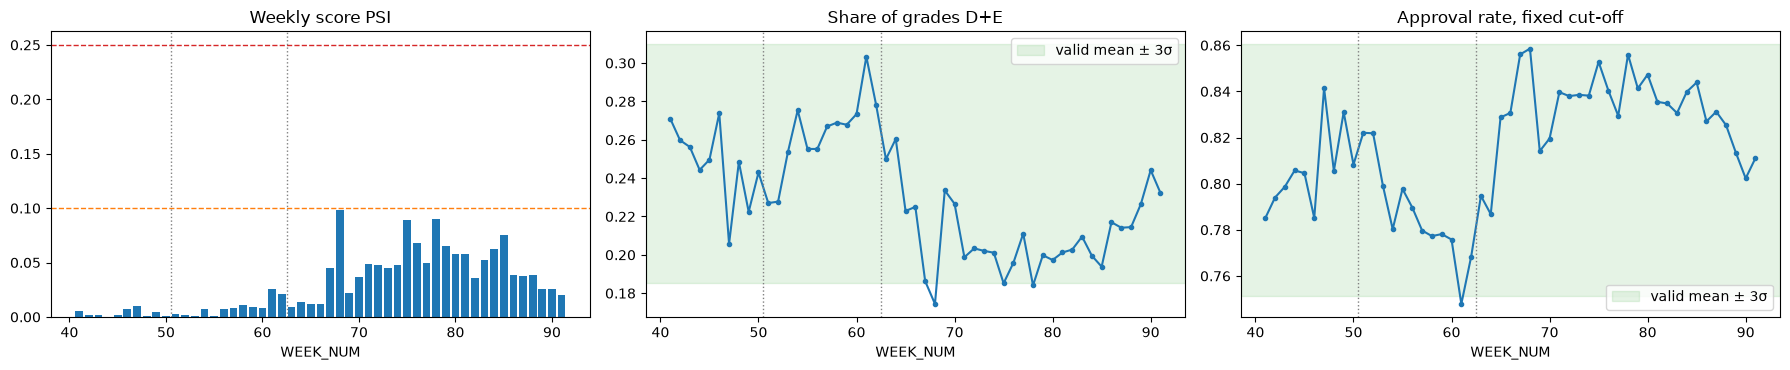

max weekly PSI in OOT: 0.098 | first PSI warning: none | first business-metric alerts: {'Share of grades D+E': 68, 'Approval rate, fixed cut-off': 61}


In [9]:
ref_r = rv["risk_SC"].to_numpy()
mon = pd.DataFrame([{"week": w, "psi": psi_by_deciles(ref_r, WEEK[w][0])} for w in range(VALID_END - 9, max(WEEK) + 1)])
wk_biz = (P.filter(pl.col("admit") & (pl.col("WEEK_NUM") > VALID_END - 10)).group_by("WEEK_NUM")
           .agg(pl.col("grade").is_in(["D", "E"]).mean().alias("de_share"), (pl.col("risk_SC") <= cut_fixed).mean().alias("rate_fixed"))
           .sort("WEEK_NUM").to_pandas())
fig, axes = plt.subplots(1, 3, figsize=(18, 3.8))
axes[0].bar(mon["week"], mon["psi"], color=np.where(mon["psi"] > 0.25, "C3", np.where(mon["psi"] > 0.1, "C1", "C0")))
axes[0].axhline(0.1, color="C1", ls="--", lw=1); axes[0].axhline(0.25, color="C3", ls="--", lw=1); axes[0].set_title("Weekly score PSI")
first, bands = {}, {}
for ax, col, title in ((axes[1], "de_share", "Share of grades D+E"), (axes[2], "rate_fixed", "Approval rate, fixed cut-off")):
    v = wk_biz[wk_biz["WEEK_NUM"] <= VALID_END][col]
    mu, sd = v.mean(), v.std(ddof=1)
    bands[col] = (mu, sd)
    ax.plot(wk_biz["WEEK_NUM"], wk_biz[col], marker="o", ms=3)
    ax.axhspan(mu - MON_SIGMA * sd, mu + MON_SIGMA * sd, color="C2", alpha=0.12, label=f"valid mean ± {MON_SIGMA:.0f}σ")
    ax.set_title(title); ax.legend()
    out = wk_biz[(wk_biz["WEEK_NUM"] > VALID_END) & ((wk_biz[col] - mu).abs() > MON_SIGMA * sd)]["WEEK_NUM"]
    first[title] = int(out.min()) if len(out) else None
for ax in axes:
    for x in (VALID_END + 0.5, OOT1_END + 0.5):
        ax.axvline(x, color="grey", ls=":", lw=1)
    ax.set_xlabel("WEEK_NUM")
plt.tight_layout(); savefig(fig, "09_monitoring"); plt.show()
psi_first = mon[(mon["week"] > VALID_END) & (mon["psi"] > 0.1)]["week"].min()
print(f"max weekly PSI in OOT: {mon.loc[mon['week'] > VALID_END, 'psi'].max():.3f} | first PSI warning: "
      f"{'none' if pd.isna(psi_first) else int(psi_first)} | first business-metric alerts: {first}")

## 7. Policy summary (`09_policy.json`)

In [10]:
v = outcome.filter(pl.col("period") == "Valid").row(0, named=True)
policy = {
    "champion": f"scorecard {SC}", "challenger": "LightGBM",
    "admission": {"age_min": AGE_MIN, "age_max": AGE_MAX,
                  "note": "no risk-based case for an upper age limit; see section 1 for the cost of 55/60/65 limits"},
    "grade_cutoffs_score": {lab: round(c) for lab, c in zip(labels, CUTS)}, "actions": action,
    "expected_on_valid": {k: v[k] for k in v if k != "period"},
    "cutoff_maintenance": {"adopted": "layer 1", "daily_mode": f"re-set weekly from the last {ROLL_WEEKS} weeks' scores to hold {BASE_RATE:.0%} approval",
                           "risk_floor": f"never looser than the validation baseline (score {-cut_fixed:.0f})",
                           "layer_2": "not adopted: lagging labels trigger after the risk has passed; revisit with leading indicators"},
    "monitoring": {"primary": f"D+E share and fixed-cut-off approval rate, alert outside validation mean +/- {MON_SIGMA:.0f} sigma",
                   "secondary": "weekly score PSI: warning 0.10, alarm 0.25",
                   "calibration": "refresh the score-to-PD mapping when lagged actual/predicted deviates from 1 by > 20%"},
}
(RES_DIR / "09_policy.json").write_text(json.dumps(policy, indent=1))
for name, df in {"09_decision_matrix": matrix, "09_policy_outcome": outcome, "09_approval_badrate": biz,
                 "09_swap_set": swap, "09_cutoff_policy_comparison": cutoff_cmp}.items():
    df.write_csv(RES_DIR / f"{name}.csv", include_bom=True)
dr.to_csv(RES_DIR / "09_cutoff_weekly.csv", index=False)
print(json.dumps(policy, indent=1))

{
 "champion": "scorecard A",
 "challenger": "LightGBM",
 "admission": {
  "age_min": 22,
  "age_max": null,
  "note": "no risk-based case for an upper age limit; see section 1 for the cost of 55/60/65 limits"
 },
 "grade_cutoffs_score": {
  "A": 628,
  "B": 607,
  "C": 587,
  "D": 565
 },
 "actions": {
  "A": "auto-approve",
  "B": "auto-approve",
  "C": "standard approve",
  "D": "manual review",
  "E": "decline"
 },
 "expected_on_valid": {
  "direct_approval_rate": 0.7464,
  "manual_review_share": 0.1454,
  "decline_rate": 0.1081,
  "bad_rate_all": 0.0368,
  "bad_rate_direct_approved": 0.0165,
  "bad_rate_manual_review": 0.0674,
  "bad_amount_share_all": 0.0406,
  "bad_amount_share_direct": 0.0203
 },
 "cutoff_maintenance": {
  "adopted": "layer 1",
  "daily_mode": "re-set weekly from the last 4 weeks' scores to hold 80% approval",
  "risk_floor": "never looser than the validation baseline (score 581)",
  "layer_2": "not adopted: lagging labels trigger after the risk has passed; rev